<a href="https://colab.research.google.com/github/kalyankargouri/Deep-Learning/blob/main/DLexper3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


x_train = x_train.reshape(-1, 784) / 255.0
x_test  = x_test.reshape(-1, 784) / 255.0


x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

def create_model(learning_rate=0.01):
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
# import math
# from tensorflow.keras import callbacks

# # Define the step decay logic
# def step_decay(epoch):
#     initial_lrate = 0.01
#     drop = 0.5
#     epochs_drop = 10.0
#     # Equation: lrate = initial * (drop ^ floor(epoch / epochs_drop))
#     lrate = initial_lrate * math.pow(drop, math.floor((1+epoch)/epochs_drop))
#     return lrate

# # Initialize the scheduler callback
# lr_scheduler = callbacks.LearningRateScheduler(step_decay, verbose=1)

# # Usage in model.fit
# history = model.fit(
#     x_train, y_train,
#     epochs=10,
#     validation_data=(x_val, y_val),
#     callbacks=[lr_scheduler]
# )

# =========================
# CELL 2: FIXED LR
# =========================

model_fixed = create_model(learning_rate=0.01)

history_fixed = model_fixed.fit(
    x_train, y_train,
    epochs=15,
    validation_data=(x_val, y_val),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8954 - loss: 0.3581 - val_accuracy: 0.9463 - val_loss: 0.1897
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9296 - loss: 0.2541 - val_accuracy: 0.9499 - val_loss: 0.1808
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9392 - loss: 0.2198 - val_accuracy: 0.9560 - val_loss: 0.1655
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9442 - loss: 0.2074 - val_accuracy: 0.9548 - val_loss: 0.1783
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9462 - loss: 0.2026 - val_accuracy: 0.9618 - val_loss: 0.1503
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9498 - loss: 0.1928 - val_accuracy: 0.9591 - val_loss: 0.1504
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9523 - loss: 0.1828 - val_accuracy: 0.9603 - val_loss: 0.1599
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9542 - loss: 0.1764 - 

In [3]:

import math

def step_decay(epoch, lr):
    drop = 0.5
    epochs_drop = 5
    return lr * drop if (epoch % epochs_drop == 0 and epoch != 0) else lr

lr_scheduler = callbacks.LearningRateScheduler(step_decay, verbose=1)

model_step = create_model(learning_rate=0.01)

history_step = model_step.fit(
    x_train, y_train,
    epochs=15,
    validation_data=(x_val, y_val),
    callbacks=[lr_scheduler],
    verbose=1
)


Epoch 1: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8943 - loss: 0.3535 - val_accuracy: 0.9398 - val_loss: 0.2088 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9269 - loss: 0.2595 - val_accuracy: 0.9394 - val_loss: 0.2038 - learning_rate: 0.0100

Epoch 3: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9370 - loss: 0.2288 - val_accuracy: 0.9509 - val_loss: 0.1579 - learning_rate: 0.0100

Epoch 4: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9429 - loss: 0.2108 - val_accuracy: 0.9592 - val_loss: 0.1474 - learning_rate: 0.0100

Epoch 5: LearningRateScheduler setting learning rate to 0.00999999

In [4]:

lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=1000,
    decay_rate=0.96,
    staircase=False
)

model_exp = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_exp.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_exp = model_exp.fit(
    x_train, y_train,
    epochs=15,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8919 - loss: 0.3621 - val_accuracy: 0.9401 - val_loss: 0.2147
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9295 - loss: 0.2501 - val_accuracy: 0.9507 - val_loss: 0.1700
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9410 - loss: 0.2130 - val_accuracy: 0.9559 - val_loss: 0.1557
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9475 - loss: 0.1879 - val_accuracy: 0.9555 - val_loss: 0.1633
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9514 - loss: 0.1710 - val_accuracy: 0.9629 - val_loss: 0.1425
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9567 - loss: 0.1564 - val_accuracy: 0.9567 - val_loss: 0.1522
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9595 - loss: 0.1465 - val_accuracy: 0.9663 - val_loss: 0.1248
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9641 - loss: 0.1294 - 

In [5]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

lr_decay = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

model_adaptive = create_model(learning_rate=0.01)

history_adaptive = model_adaptive.fit(
    x_train, y_train,
    epochs=20,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, lr_decay],
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8934 - loss: 0.3551 - val_accuracy: 0.9467 - val_loss: 0.1837 - learning_rate: 0.0100
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9254 - loss: 0.2594 - val_accuracy: 0.9467 - val_loss: 0.2034 - learning_rate: 0.0100
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9356 - loss: 0.2405 - val_accuracy: 0.9528 - val_loss: 0.1768 - learning_rate: 0.0100
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9410 - loss: 0.2182 - val_accuracy: 0.9562 - val_loss: 0.1660 - learning_rate: 0.0100
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9453 - loss: 0.2071 - val_accuracy: 0.9580 - val_loss: 0.1776 - learning_rate: 0.0100
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9498 - loss: 0.1911
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9491 - lo

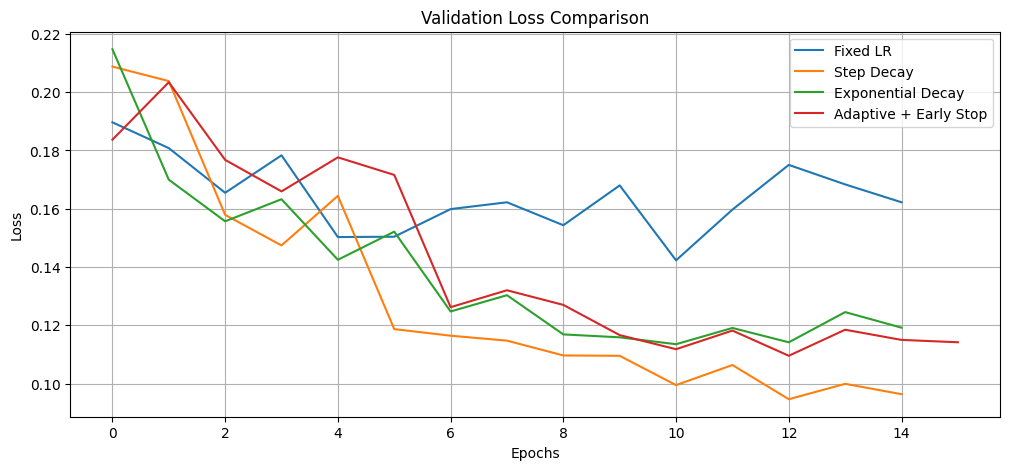

In [6]:
# =========================
# CELL 6: COMPARISON
# =========================

plt.figure(figsize=(12,5))

plt.plot(history_fixed.history['val_loss'], label='Fixed LR')
plt.plot(history_step.history['val_loss'], label='Step Decay')
plt.plot(history_exp.history['val_loss'], label='Exponential Decay')
plt.plot(history_adaptive.history['val_loss'], label='Adaptive + Early Stop')

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

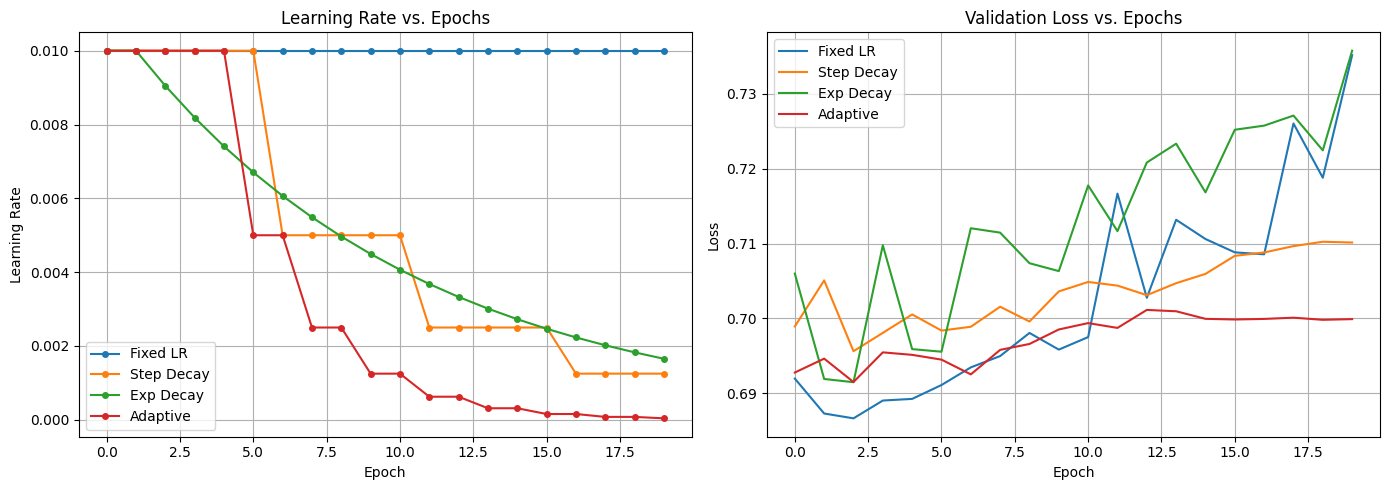

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import matplotlib.pyplot as plt

# 1. Setup Synthetic Data (to ensure the code runs without external datasets)
x_train = np.random.random((1000, 20))
y_train = np.random.randint(0, 2, (1000,))
x_val = np.random.random((200, 20))
y_val = np.random.randint(0, 2, (200,))

# 2. Scheduling Functions
def step_decay(epoch):
    initial_lr = 0.01
    drop = 0.5
    epochs_drop = 5
    return float(initial_lr * (drop ** (epoch // epochs_drop)))

def exp_decay(epoch):
    initial_lr = 0.01
    k = 0.1
    return float(initial_lr * np.exp(-k * epoch))

# 3. Training Function
def train_model(name, callback_list=None, initial_lr=0.01):
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(20,)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=initial_lr),
                  loss='binary_crossentropy')

    # Custom callback to capture LR at each epoch
    class LRHistory(callbacks.Callback):
        def on_epoch_begin(self, epoch, logs=None):
            if not hasattr(self, 'lrs'): self.lrs = []
            self.lrs.append(float(tf.keras.backend.get_value(self.model.optimizer.learning_rate)))

    lr_tracker = LRHistory()
    cbs = [lr_tracker] + (callback_list if callback_list else [])

    history = model.fit(x_train, y_train, epochs=20, validation_data=(x_val, y_val),
                        callbacks=cbs, verbose=0)
    return history.history['val_loss'], lr_tracker.lrs

# 4. Run Comparisons
results = {
    'Fixed LR': train_model('Fixed'),
    'Step Decay': train_model('Step', [callbacks.LearningRateScheduler(step_decay)]),
    'Exp Decay': train_model('Exp', [callbacks.LearningRateScheduler(exp_decay)]),
    'Adaptive': train_model('Adaptive', [callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)])
}

# 5. Visualization
plt.figure(figsize=(14, 5))

# Plot 1: Learning Rate Behavior
plt.subplot(1, 2, 1)
for name, (loss, lrs) in results.items():
    plt.plot(lrs, label=name, marker='o', markersize=4)
plt.title('Learning Rate vs. Epochs')
plt.xlabel('Epoch'); plt.ylabel('Learning Rate'); plt.legend(); plt.grid(True)

# Plot 2: Convergence (Validation Loss)
plt.subplot(1, 2, 2)
for name, (loss, lrs) in results.items():
    plt.plot(loss, label=name)
plt.title('Validation Loss vs. Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()